In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        print(os.path.join(root, f))

/content/drive/MyDrive/UTKFace.jpg.chip.zip
/content/drive/MyDrive/Untitled document.gdoc
/content/drive/MyDrive/opencv_face_detector_uint8.pb
/content/drive/MyDrive/opencv_face_detector.pbtxt
/content/drive/MyDrive/Colab Notebooks/GenderAgeDetection.ipynb
/content/drive/MyDrive/Colab Notebooks/AgeDetection.ipynb
/content/drive/MyDrive/Samadhan Doc's/Aadhar Card.pdf
/content/drive/MyDrive/Samadhan Doc's/PAN Card.pdf
/content/drive/MyDrive/Samadhan Doc's/Bank Passbook BOI.pdf
/content/drive/MyDrive/Samadhan Doc's/Debit Card BOI (ATM).pdf
/content/drive/MyDrive/Samadhan Doc's/Covid Certificate.pdf
/content/drive/MyDrive/Samadhan Doc's/Passport Size Photo.pdf
/content/drive/MyDrive/Samadhan Doc's/Sign.pdf
/content/drive/MyDrive/Samadhan Doc's/10th certificate.pdf
/content/drive/MyDrive/Samadhan Doc's/12th certificate.pdf
/content/drive/MyDrive/Samadhan Doc's/10th LC.pdf
/content/drive/MyDrive/Samadhan Doc's/12th LC.pdf
/content/drive/MyDrive/Samadhan Doc's/PM Vidyalakshi Application.pdf
/

In [ ]:
import zipfile, os

print("⏳ Extracting... please wait (may take 2-3 mins)")

with zipfile.ZipFile("/content/drive/MyDrive/UTKFace.jpg.chip.zip", 'r') as z:
    z.extractall("/content/UTKFace/")

DATASET_PATH = "/content/UTKFace/"
files = os.listdir(DATASET_PATH)
print(f"✅ Done! Total images: {len(files)}")
print(f"Sample filename: {files[0]}")

⏳ Extracting... please wait (may take 2-3 mins)
✅ Done! Total images: 23708
Sample filename: 62_1_3_20170119211556000.jpg.chip.jpg


# **PHASE 1 — Explore Dataset**

✅ Valid images: 23687
Age range: 1 to 100
Male: 12386 | Female: 11301


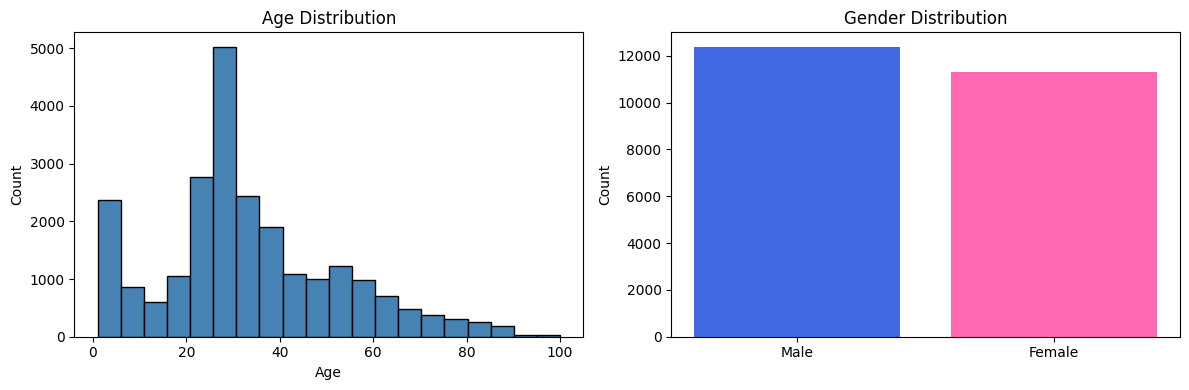


Sample filenames:
  38_1_0_20170117121922741.jpg.chip.jpg
  40_1_2_20170116183042122.jpg.chip.jpg
  30_1_0_20170117174710486.jpg.chip.jpg


In [ ]:
import os
import matplotlib.pyplot as plt
from collections import Counter

DATASET_PATH = "/content/UTKFace/"

ages = []
genders = []
filenames = []

for fname in os.listdir(DATASET_PATH):
    parts = fname.split("_")
    if len(parts) < 3:
        continue
    try:
        age = int(parts[0])
        gender = int(parts[1])
        if age < 1 or age > 100:
            continue
        ages.append(age)
        genders.append(gender)
        filenames.append(fname)
    except ValueError:
        continue

print(f"✅ Valid images: {len(filenames)}")
print(f"Age range: {min(ages)} to {max(ages)}")
print(f"Male: {genders.count(0)} | Female: {genders.count(1)}")

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(ages, bins=20, color='steelblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.bar(["Male", "Female"], [genders.count(0), genders.count(1)],
        color=['royalblue', 'hotpink'])
plt.title("Gender Distribution")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print(f"\nSample filenames:")
for f in filenames[:3]:
    print(f"  {f}")

# **PHASE 2 — Preprocess & Save Data**

⏳ Loading and processing images...
  Processed 5000 images...
  Processed 10000 images...
  Processed 15000 images...
  Processed 20000 images...

✅ Done!
X shape: (23687, 64, 64, 3)
y_gender shape: (23687,)
y_age shape: (23687,)
Pixel range: 0.0 to 1.0

✅ Saved to Google Drive!


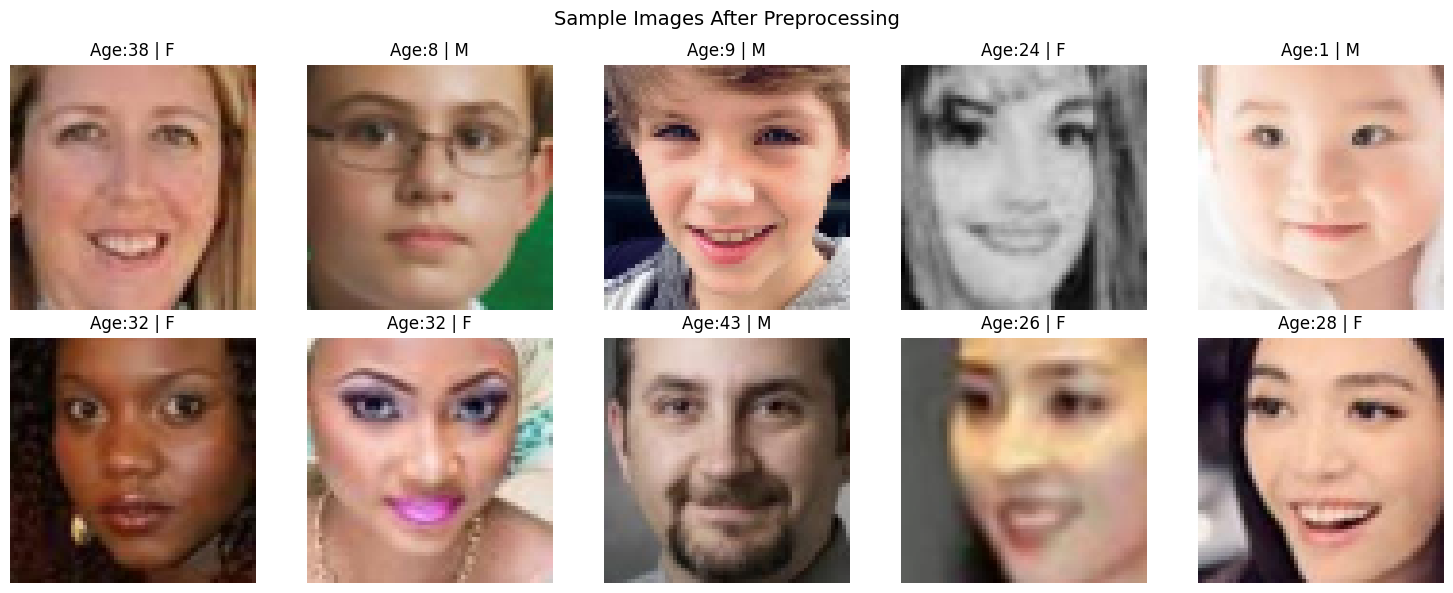

In [ ]:
import cv2
import numpy as np
import os

DATASET_PATH = "/content/UTKFace/"
IMG_SIZE = 64

X = []
y_gender = []
y_age = []

print("⏳ Loading and processing images...")

for i, fname in enumerate(os.listdir(DATASET_PATH)):
    parts = fname.split("_")
    if len(parts) < 3:
        continue
    try:
        age = int(parts[0])
        gender = int(parts[1])
        if age < 1 or age > 100:
            continue
    except ValueError:
        continue

    img_path = os.path.join(DATASET_PATH, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    X.append(img)
    y_gender.append(gender)
    y_age.append(age)

    # Progress update every 5000 images
    if (i+1) % 5000 == 0:
        print(f"  Processed {i+1} images...")

# Convert to numpy arrays
X = np.array(X, dtype='float32') / 255.0
y_gender = np.array(y_gender)
y_age = np.array(y_age)

print(f"\n✅ Done!")
print(f"X shape: {X.shape}")
print(f"y_gender shape: {y_gender.shape}")
print(f"y_age shape: {y_age.shape}")
print(f"Pixel range: {X.min():.1f} to {X.max():.1f}")

# Save to disk
os.makedirs("/content/drive/MyDrive/DeepLearning/models", exist_ok=True)

np.save("/content/drive/MyDrive/DeepLearning/models/X.npy", X)
np.save("/content/drive/MyDrive/DeepLearning/models/y_gender.npy", y_gender)
np.save("/content/drive/MyDrive/DeepLearning/models/y_age.npy", y_age)

print("\n✅ Saved to Google Drive!")

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i*500])
    ax.set_title(f"Age:{y_age[i*500]} | {'M' if y_gender[i*500]==0 else 'F'}")
    ax.axis("off")
plt.suptitle("Sample Images After Preprocessing", fontsize=14)
plt.tight_layout()
plt.show()

# **PHASE 3 — Train Gender Model**

✅ Data loaded: (23687, 64, 64, 3)
Train: (18949, 64, 64, 3) | Test: (4738, 64, 64, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,237,985 (8.54 MB)

 Trainable params: 2,237,537 (8.54 MB)

 Non-trainable params: 448 (1.75 KB)


⏳ Training started...
Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 519s 2s/step - accuracy: 0.7212 - loss: 0.6911 - val_accuracy: 0.5673 - val_loss: 1.7877 - learning_rate: 0.0010
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 516s 2s/step - accuracy: 0.8338 - loss: 0.3680 - val_accuracy: 0.8542 - val_loss: 0.3645 - learning_rate: 0.0010
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 551s 2s/step - accuracy: 0.8529 - loss: 0.3290 - val_accuracy: 0.8879 - val_loss: 0.2759 - learning_rate: 0.0010
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 571s 2s/step - accuracy: 0.8678 - loss: 0.3004 - val_accuracy: 0.8763 - val_loss: 0.2773 - learning_rate: 0.0010
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 511s 2s/step - accuracy: 0.8786 - loss: 0.2782 - val_accuracy: 0.8670 - val_loss: 0.2848 - learning_rate: 0.0010
Epoch 6/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.8836 - loss: 0.2657 - val_accuracy: 0.8926 - val_loss: 0.2505 - learning_rate: 0.0010
Epoch 7/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accu


✅ Gender model saved!


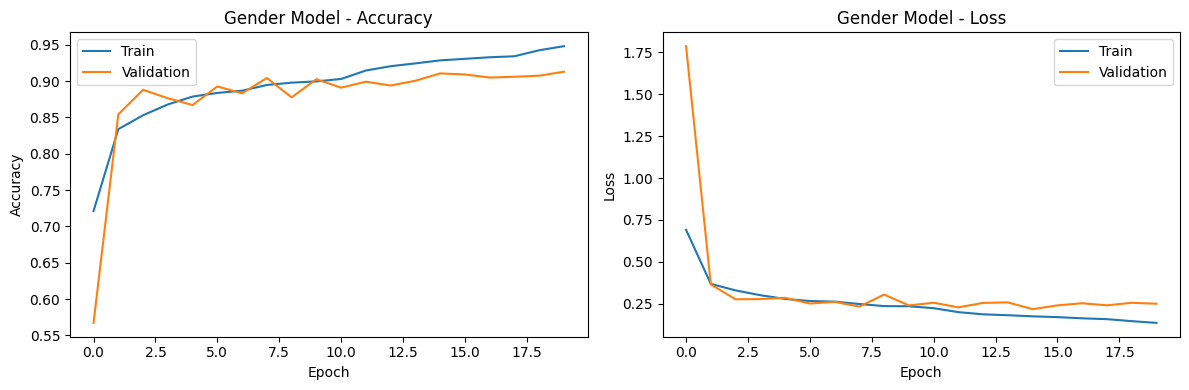


🎯 Best Validation Accuracy: 91.28%


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Load saved data
X = np.load("/content/drive/MyDrive/DeepLearning/models/X.npy")
y_gender = np.load("/content/drive/MyDrive/DeepLearning/models/y_gender.npy")

print(f"✅ Data loaded: {X.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_gender, test_size=0.2, random_state=42, stratify=y_gender
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Build CNN
def build_gender_model():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Dense layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # 0=Male, 1=Female
    ])
    return model

model = build_gender_model()
model.summary()

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
print("\n⏳ Training started...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.5, patience=3, verbose=1)
    ]
)

# Save model
model.save("/content/drive/MyDrive/DeepLearning/models/gender_model.h5")
print("\n✅ Gender model saved!")

# Plot results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Gender Model - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Gender Model - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

best_acc = max(history.history['val_accuracy']) * 100
print(f"\n🎯 Best Validation Accuracy: {best_acc:.2f}%")

# **PHASE 4 — Train Age Model**

✅ Data loaded: (23687, 64, 64, 3)
Train: (18949, 64, 64, 3) | Test: (4738, 64, 64, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,237,985 (8.54 MB)

 Trainable params: 2,237,537 (8.54 MB)

 Non-trainable params: 448 (1.75 KB)


⏳ Age model training started...
Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - loss: 0.4432 - mae: 0.4432 - val_loss: 7.8459 - val_mae: 7.8459 - learning_rate: 0.0010
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 611s 2s/step - loss: 0.1329 - mae: 0.1329 - val_loss: 0.7349 - val_mae: 0.7349 - learning_rate: 0.0010
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - loss: 0.1229 - mae: 0.1229 - val_loss: 1.3019 - val_mae: 1.3019 - learning_rate: 0.0010
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - loss: 0.1176 - mae: 0.1176 - val_loss: 0.6955 - val_mae: 0.6955 - learning_rate: 0.0010
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 635s 2s/step - loss: 0.1146 - mae: 0.1146 - val_loss: 0.1314 - val_mae: 0.1314 - learning_rate: 0.0010
Epoch 6/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 623s 2s/step - loss: 0.1130 - mae: 0.1130 - val_loss: 0.1097 - val_mae: 0.1097 - learning_rate: 0.0010
Epoch 7/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 578s 2s/step - loss: 0.1128 - mae: 0.1128 - val_loss: 0.1393 - val_ma


✅ Age model saved!


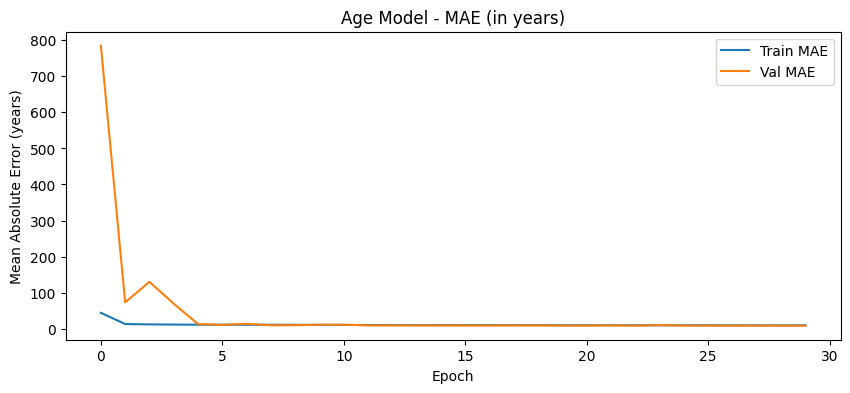


🎯 Best Validation MAE: 8.61 years


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data
X = np.load("/content/drive/MyDrive/DeepLearning/models/X.npy")
y_age = np.load("/content/drive/MyDrive/DeepLearning/models/y_age.npy")

print(f"✅ Data loaded: {X.shape}")

# Normalize age to [0, 1]
y_age_norm = y_age / 100.0

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_age_norm, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Same CNN but for REGRESSION
def build_age_model():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Dense
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        # OUTPUT: linear activation for regression (not sigmoid!)
        layers.Dense(1, activation='linear')
    ])
    return model

model = build_age_model()
model.summary()

# Compile with MAE loss (not binary_crossentropy!)
model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

print("\n⏳ Age model training started...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.5, patience=3, verbose=1)
    ]
)

# Save model
model.save("/content/drive/MyDrive/DeepLearning/models/age_model.h5")
print("\n✅ Age model saved!")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(np.array(history.history['mae'])*100, label='Train MAE')
plt.plot(np.array(history.history['val_mae'])*100, label='Val MAE')
plt.title("Age Model - MAE (in years)")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error (years)")
plt.legend()
plt.show()

best_mae = min(history.history['val_mae']) * 100
print(f"\n🎯 Best Validation MAE: {best_mae:.2f} years")

In [7]:
# Fixed confidence display
def predict_gender_age(face_img):
    img = cv2.resize(face_img, (64, 64))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)

    gender_prob = gender_model.predict(img, verbose=0)[0][0]
    gender = GENDER_LABELS[int(gender_prob > 0.5)]
    confidence = round(float(gender_prob if gender_prob > 0.5 else 1 - gender_prob) * 100, 1)
    age = int(age_model.predict(img, verbose=0)[0][0] * 100)
    age = max(1, min(100, age))
    return gender, confidence, age

print("✅ Function updated!")

✅ Function updated!


# **PHASE 5 — Evaluate Both Models**

✅ Both models loaded!

=== GENDER MODEL EVALUATION ===
149/149 ━━━━━━━━━━━━━━━━━━━━ 38s 253ms/step
              precision    recall  f1-score   support

        Male       0.96      0.93      0.95      2516
      Female       0.92      0.96      0.94      2222

    accuracy                           0.94      4738
   macro avg       0.94      0.94      0.94      4738
weighted avg       0.94      0.94      0.94      4738



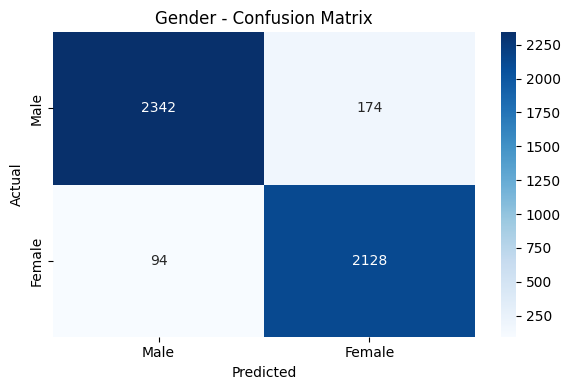


=== AGE MODEL EVALUATION ===
149/149 ━━━━━━━━━━━━━━━━━━━━ 31s 203ms/step
Mean Absolute Error: 8.61 years


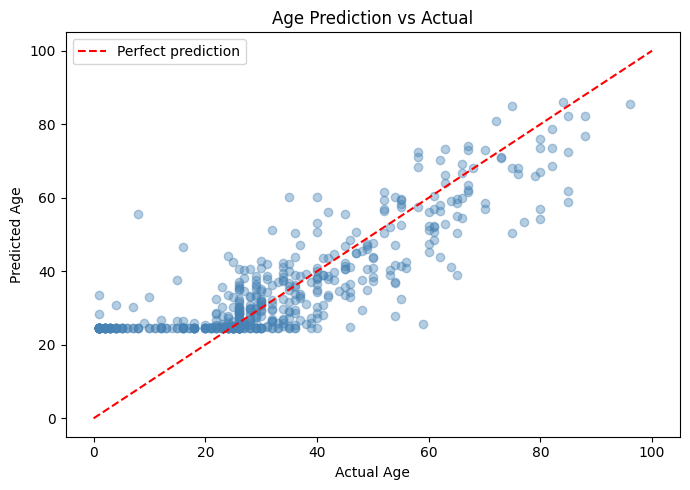


MAE by Age Group:
  Child/Teen (1-20): MAE = 17.94 years  (946 samples)
  Young Adult (21-40): MAE = 4.52 years  (2453 samples)
  Middle Age (41-60): MAE = 8.05 years  (819 samples)
  Senior (61-100): MAE = 11.78 years  (520 samples)


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
X = np.load("/content/drive/MyDrive/DeepLearning/models/X.npy")
y_gender = np.load("/content/drive/MyDrive/DeepLearning/models/y_gender.npy")
y_age = np.load("/content/drive/MyDrive/DeepLearning/models/y_age.npy")

# Fix: add compile=False
gender_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DeepLearning/models/gender_model.h5",
    compile=False)
age_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DeepLearning/models/age_model.h5",
    compile=False)
print("✅ Both models loaded!")

# Split
_, X_test_g, _, y_test_g = train_test_split(X, y_gender, test_size=0.2, random_state=42)
_, X_test_a, _, y_test_a = train_test_split(X, y_age/100.0, test_size=0.2, random_state=42)

# ── GENDER EVALUATION ──────────────────────────────
print("\n=== GENDER MODEL EVALUATION ===")
g_preds = (gender_model.predict(X_test_g) > 0.5).astype(int).flatten()
print(classification_report(y_test_g, g_preds, target_names=["Male", "Female"]))

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test_g, g_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Male","Female"],
            yticklabels=["Male","Female"],
            cmap="Blues")
plt.title("Gender - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# ── AGE EVALUATION ─────────────────────────────────
print("\n=== AGE MODEL EVALUATION ===")
a_preds = age_model.predict(X_test_a).flatten() * 100
y_test_real = y_test_a * 100

mae = np.mean(np.abs(a_preds - y_test_real))
print(f"Mean Absolute Error: {mae:.2f} years")

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test_real[:500], a_preds[:500], alpha=0.4, color='steelblue')
plt.plot([0,100], [0,100], 'r--', label='Perfect prediction')
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Age Prediction vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

# Age error by group
print("\nMAE by Age Group:")
groups = [(1,20,"Child/Teen"), (21,40,"Young Adult"), (41,60,"Middle Age"), (61,100,"Senior")]
for low, high, name in groups:
    mask = (y_test_real >= low) & (y_test_real <= high)
    if mask.sum() > 0:
        group_mae = np.mean(np.abs(a_preds[mask] - y_test_real[mask]))
        print(f"  {name} ({low}-{high}): MAE = {group_mae:.2f} years  ({mask.sum()} samples)")

# **PHASE 6 — Detect on Image**


In [1]:
from google.colab import files
uploaded = files.upload()

Saving opencv_face_detector.pbtxt to opencv_face_detector.pbtxt
Saving opencv_face_detector_uint8.pb to opencv_face_detector_uint8.pb


In [16]:
from google.colab import files
photo = files.upload()  # upload any photo with a face (your photo, or any person's photo)

Saving EZZaaaHXQAUEYJx.jpg to EZZaaaHXQAUEYJx.jpg


In [17]:
import os

print("Current directory:", os.getcwd())

for f in [
    "opencv_face_detector_uint8.pb",
    "opencv_face_detector.pbtxt"
]:
    print(f, "->", os.path.exists(f))

Current directory: /content
opencv_face_detector_uint8.pb -> True
opencv_face_detector.pbtxt -> True


Face 1: Male (100.0%) | Age: 32


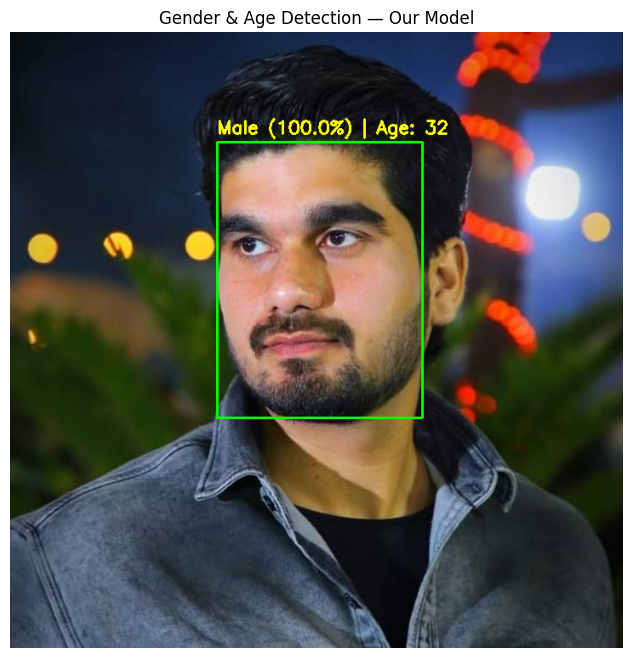


✅ Total faces detected: 1


In [18]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Load your trained models
gender_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DeepLearning/models/gender_model.h5",
    compile=False)
age_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/DeepLearning/models/age_model.h5",
    compile=False)

# Load face detector
face_net = cv2.dnn.readNet(
    "opencv_face_detector_uint8.pb",
    "opencv_face_detector.pbtxt")

GENDER_LABELS = ["Male", "Female"]

def predict_gender_age(face_img):
    img = cv2.resize(face_img, (64, 64))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)

    gender_prob = gender_model.predict(img, verbose=0)[0][0]
    gender = GENDER_LABELS[int(gender_prob > 0.5)]
    confidence = gender_prob if gender_prob > 0.5 else 1 - gender_prob
    age = int(age_model.predict(img, verbose=0)[0][0] * 100)
    age = max(1, min(100, age))
    return gender, round(confidence*100, 1), age

# Get uploaded image
image_path = list(photo.keys())[0]
frame = cv2.imread(image_path)

# Detect faces
h, w = frame.shape[:2]
blob = cv2.dnn.blobFromImage(frame, 1.0, (300,300),
                              [104,117,123], swapRB=False)
face_net.setInput(blob)
detections = face_net.forward()

result = frame.copy()
face_count = 0

for i in range(detections.shape[2]):
    conf = detections[0,0,i,2]
    if conf > 0.7:
        x1 = int(detections[0,0,i,3] * w)
        y1 = int(detections[0,0,i,4] * h)
        x2 = int(detections[0,0,i,5] * w)
        y2 = int(detections[0,0,i,6] * h)

        face = frame[max(0,y1):y2, max(0,x1):x2]
        if face.size == 0:
            continue

        gender, gender_conf, age = predict_gender_age(face)
        label = f"{gender} ({gender_conf}%) | Age: {age}"

        cv2.rectangle(result, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(result, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)
        face_count += 1
        print(f"Face {face_count}: {label}")

# Show result
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(result_rgb)
plt.axis("off")
plt.title("Gender & Age Detection — Our Model")
plt.show()

print(f"\n✅ Total faces detected: {face_count}")

# **Fixed Function**

In [19]:
# Fix confidence display
def predict_gender_age(face_img):
    img = cv2.resize(face_img, (64, 64))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)

    gender_prob = gender_model.predict(img, verbose=0)[0][0]
    gender = GENDER_LABELS[int(gender_prob > 0.5)]
    confidence = round(float(gender_prob if gender_prob > 0.5 else 1 - gender_prob) * 100, 1)
    age = int(age_model.predict(img, verbose=0)[0][0] * 100)
    age = max(1, min(100, age))
    return gender, confidence, age

print("✅ Function updated!")

✅ Function updated!


# **Phase 7 — Live Webcam!**

In [47]:
# Cell 1 — Capture photo from webcam
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture Photo';
            capture.style.fontSize = '20px';
            capture.style.padding = '10px';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            video.width = 640;
            div.appendChild(video);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            div.remove();
            return canvas.toDataURL('image/jpeg', 0.8);
        }
        takePhoto();
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    with open('webcam_photo.jpg', 'wb') as f:
        f.write(binary)
    print("✅ Photo captured!")
    return 'webcam_photo.jpg'

# Take photo
photo_path = take_photo()

<IPython.core.display.Javascript object>

✅ Photo captured!


✅ Male (86.6%) | Age: 24


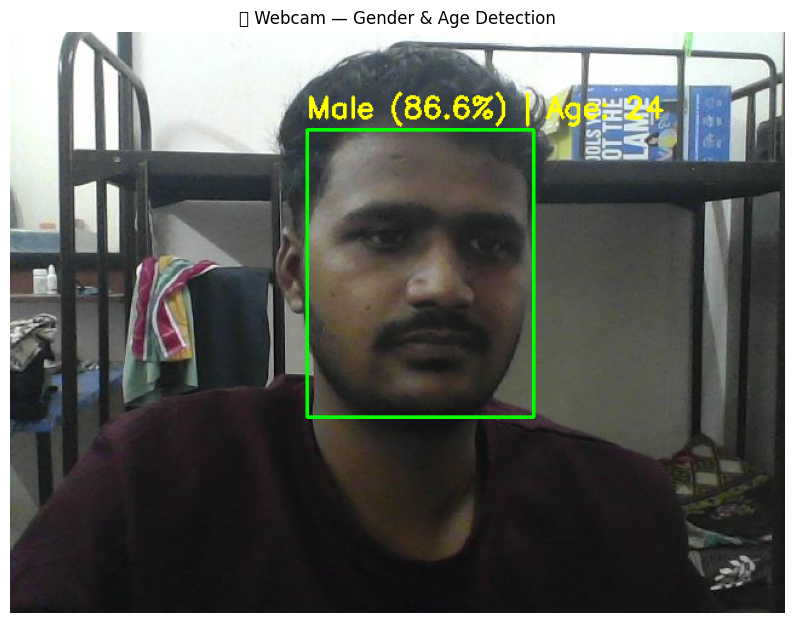

Total faces detected: 1


In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Detect on webcam photo
frame = cv2.imread('webcam_photo.jpg')
h, w = frame.shape[:2]

blob = cv2.dnn.blobFromImage(frame, 1.0, (300,300),
                              [104,117,123], swapRB=False)
face_net.setInput(blob)
detections = face_net.forward()

result = frame.copy()
face_count = 0

for i in range(detections.shape[2]):
    conf = detections[0,0,i,2]
    if conf > 0.7:
        x1 = int(detections[0,0,i,3] * w)
        y1 = int(detections[0,0,i,4] * h)
        x2 = int(detections[0,0,i,5] * w)
        y2 = int(detections[0,0,i,6] * h)

        face = frame[max(0,y1):y2, max(0,x1):x2]
        if face.size == 0:
            continue

        gender, gender_conf, age = predict_gender_age(face)
        label = f"{gender} ({gender_conf}%) | Age: {age}"

        cv2.rectangle(result, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(result, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)
        face_count += 1
        print(f"✅ {label}")

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(result_rgb)
plt.axis("off")
plt.title("📸 Webcam — Gender & Age Detection")
plt.show()
print(f"Total faces detected: {face_count}")